In [8]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, roc_curve, confusion_matrix, classification_report, precision_recall_curve
import matplotlib.pyplot as plt
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE

In [9]:
df = pd.read_csv("creditcard.csv")
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [10]:
print(df["Class"].value_counts())
print(df["Class"].value_counts(normalize=True) * 100)

Class
0    284315
1       492
Name: count, dtype: int64
Class
0    99.827251
1     0.172749
Name: proportion, dtype: float64


In [11]:
X = df.drop(columns=["Class"])
y = df["Class"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [12]:
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

print("Before SMOTE:", y_train.value_counts().to_dict())
print("After SMOTE:", y_train_resampled.value_counts().to_dict())

Before SMOTE: {0: 227451, 1: 394}
After SMOTE: {0: 227451, 1: 227451}


In [13]:
model = XGBClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.1,
    eval_metric="logloss",
    random_state=42
)

model.fit(X_train_resampled, y_train_resampled)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,True
,eval_metric,'logloss'


In [14]:
y_proba = model.predict_proba(X_test)[:, 1]
y_pred = model.predict(X_test)

auc_score = roc_auc_score(y_test, y_proba)
print(f"ROC-AUC Score: {auc_score:.4f}")
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

ROC-AUC Score: 0.9826
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.64      0.87      0.74        98

    accuracy                           1.00     56962
   macro avg       0.82      0.93      0.87     56962
weighted avg       1.00      1.00      1.00     56962

[[56817    47]
 [   13    85]]


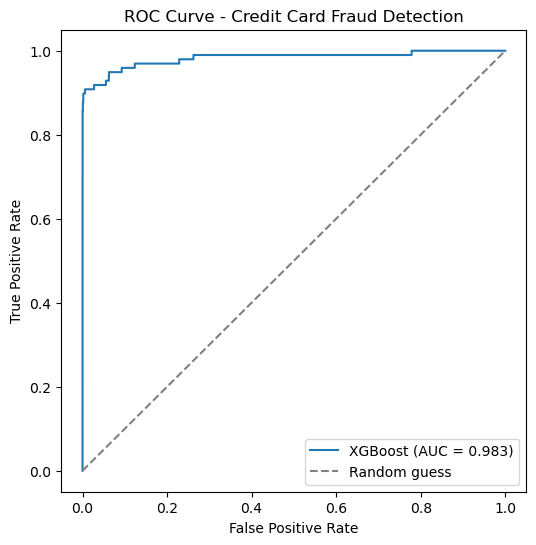

In [15]:
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, label=f"XGBoost (AUC = {auc_score:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random guess")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Credit Card Fraud Detection")
plt.legend()
plt.show()

In [16]:
for threshold in [0.5, 0.3, 0.1]:
    y_pred_t = (y_proba >= threshold).astype(int)
    print(f"\n--- Threshold = {threshold} ---")
    print(confusion_matrix(y_test, y_pred_t))
    print(classification_report(y_test, y_pred_t, digits=3))


--- Threshold = 0.5 ---
[[56817    47]
 [   13    85]]
              precision    recall  f1-score   support

           0      1.000     0.999     0.999     56864
           1      0.644     0.867     0.739        98

    accuracy                          0.999     56962
   macro avg      0.822     0.933     0.869     56962
weighted avg      0.999     0.999     0.999     56962


--- Threshold = 0.3 ---
[[56777    87]
 [   12    86]]
              precision    recall  f1-score   support

           0      1.000     0.998     0.999     56864
           1      0.497     0.878     0.635        98

    accuracy                          0.998     56962
   macro avg      0.748     0.938     0.817     56962
weighted avg      0.999     0.998     0.999     56962


--- Threshold = 0.1 ---
[[56623   241]
 [   10    88]]
              precision    recall  f1-score   support

           0      1.000     0.996     0.998     56864
           1      0.267     0.898     0.412        98

    accuracy  

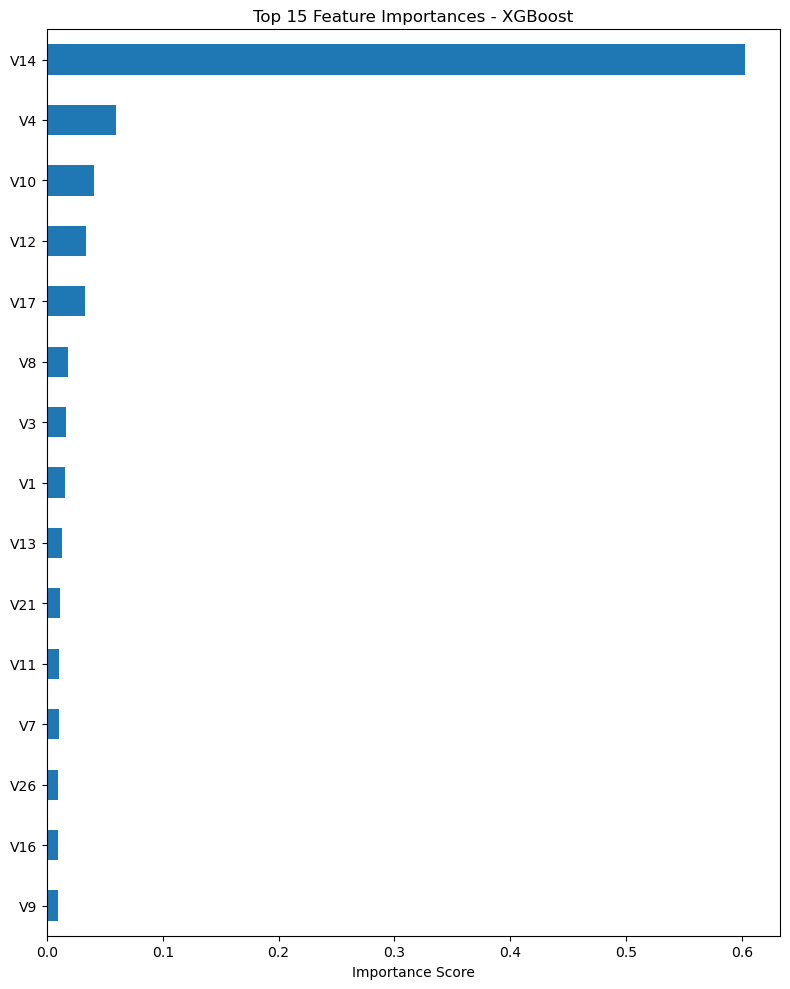

V14    0.602862
V4     0.059539
V10    0.040975
V12    0.033406
V17    0.032915
V8     0.018249
V3     0.016363
V1     0.015348
V13    0.013164
V21    0.010847
V11    0.010712
V7     0.010056
V26    0.009718
V16    0.009630
V9     0.009186
dtype: float32


In [17]:
importances = model.feature_importances_
feat_names = X.columns

feat_imp = pd.Series(importances, index=feat_names).sort_values(ascending=False)

plt.figure(figsize=(8, 10))
feat_imp.head(15).plot(kind="barh")
plt.gca().invert_yaxis()
plt.xlabel("Importance Score")
plt.title("Top 15 Feature Importances - XGBoost")
plt.tight_layout()
plt.show()

print(feat_imp.head(15))